In [132]:
import os
import json
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.cm as cm
from pesummary.io import read
from simple_pe.param_est import SimplePESamples
from simple_pe.waveforms import parameter_bounds

import logging
_logger = logging.getLogger('PESummary')
_logger.setLevel(logging.CRITICAL + 10)
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [182]:
def summary_plot(delta_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=None, ylims=None):

    # Loop through injections:
    inj_params = []
    delta_meds = []
    delta_errs = []
    c_vals = []
    failed_inds = []
    for i, inj_dir in tqdm(enumerate(sorted(os.listdir(injections_dir)))):
        inj_dir = os.path.join(injections_dir, inj_dir)
        inj_dir = os.path.join(inj_dir, 'outdir/output/')
        
        # Get inj_param, delta_true, and c_val
        inj_path = os.path.join(inj_dir, 'converted_injection_parameters.json')
        with open(inj_path, 'r') as f:
            inj_dict = json.load(f)
        inj_param = inj_dict['posterior_samples'][inj_lbl]
        delta_true = inj_dict['posterior_samples'][delta_lbl]
        c_val = inj_dict['posterior_samples'][colour_lbl]
        inj_params.append(inj_param)
        c_vals.append(c_val)

        # Check run finished properly, if so get samples on delta parameter
        if 'posterior_samples.dat' not in os.listdir(inj_dir):
            failed_inds.append(i)
        else:
            samples_path = os.path.join(inj_dir, 'posterior_samples.dat')
            samples = SimplePESamples(read(samples_path).samples_dict)
            samples.generate_all_posterior_samples()
            samples_delta = samples[delta_lbl]
            quants = np.quantile(samples_delta, [0.05, 0.5, 0.95])
            if err_type == 'rel':
                quants /= delta_true
            elif err_type == 'abs':
                quants -= delta_true
            elif err_type == 'base':
                if delta_lbl != inj_lbl:
                    raise ValueError('delta_lbl must equal inj_lbl for base err_type')
                quants = quants
            else:
                raise ValueError('Incorrect err_type')
            delta_meds.append(quants[1])
            delta_errs.append([quants[1] - quants[0], quants[2] - quants[1]])

    # Plot failed runs
    plt.figure(figsize=(10, 7.5))
    for ind in failed_inds:
        plt.axvline(inj_params[ind], c='r', lw=1)
    inj_params = np.delete(inj_params, failed_inds)
    c_vals = np.delete(c_vals, failed_inds)

    # Plot errors
    sc = plt.scatter(inj_params, delta_meds, c=c_vals)
    clb = plt.colorbar(sc, label=f'Injected {colour_lbl}')
    norm = matplotlib.colors.Normalize(vmin=min(c_vals), vmax=max(c_vals))
    mapper = cm.ScalarMappable(norm=norm, cmap='viridis')
    c_arr = np.array([(mapper.to_rgba(c_val)) for c_val in c_vals])
    for x, y, e, c in zip(inj_params, delta_meds, delta_errs, c_arr):
        plt.errorbar(x, y, yerr=np.array([e]).T, color=c, capsize=5)

    # Plot invalid regions of identical parameters (assume default param bounds)
    plt.xlim(xlims)
    plt.ylim(ylims)
    if delta_lbl == inj_lbl:
        xlims = plt.gca().get_xlim()
        ylims = plt.gca().get_ylim()
        param_mins = SimplePESamples(parameter_bounds.param_mins)
        param_maxs = SimplePESamples(parameter_bounds.param_maxs)
        param_mins.generate_all_posterior_samples()
        param_maxs.generate_all_posterior_samples()
        min_param = param_mins[delta_lbl]
        max_param = param_maxs[delta_lbl]
        if min_param > max_param:
            min_param, max_param = max_param, min_param
        x_arr = np.linspace(xlims[0], xlims[1], 1001)
        if err_type == 'rel':
            min_bound = min_param / x_arr
            max_bound = max_param / x_arr
        elif err_type == 'abs':
            min_bound = min_param - x_arr
            max_bound = max_param - x_arr
        elif err_type == 'base':
            min_bound = min_param
            max_bound = max_param
        plt.fill_between(x_arr, ylims[0], min_bound, color='k', alpha=0.5, zorder=0)
        plt.fill_between(x_arr, max_bound, ylims[1], color='k', alpha=0.5, zorder=0)

    # Plot formatting
    plt.xlabel(f'Injected {inj_lbl}')
    if err_type == 'rel':
        plt.axhline(1, c='k', ls='dashed')
        plt.ylabel(f'Relative {delta_lbl} error')
    elif err_type == 'abs':
        plt.axhline(0, c='k', ls='dashed')
        plt.ylabel(f'Absolute {delta_lbl} error')
    elif err_type == 'base':
        xlims = plt.gca().get_xlim()
        x_arr = np.linspace(xlims[0], xlims[1], 1001)
        plt.plot(x_arr, x_arr, c='k', ls='dashed')
        plt.ylabel(f'Recovered {delta_lbl}')
    plt.show()       

50it [00:04, 11.45it/s]


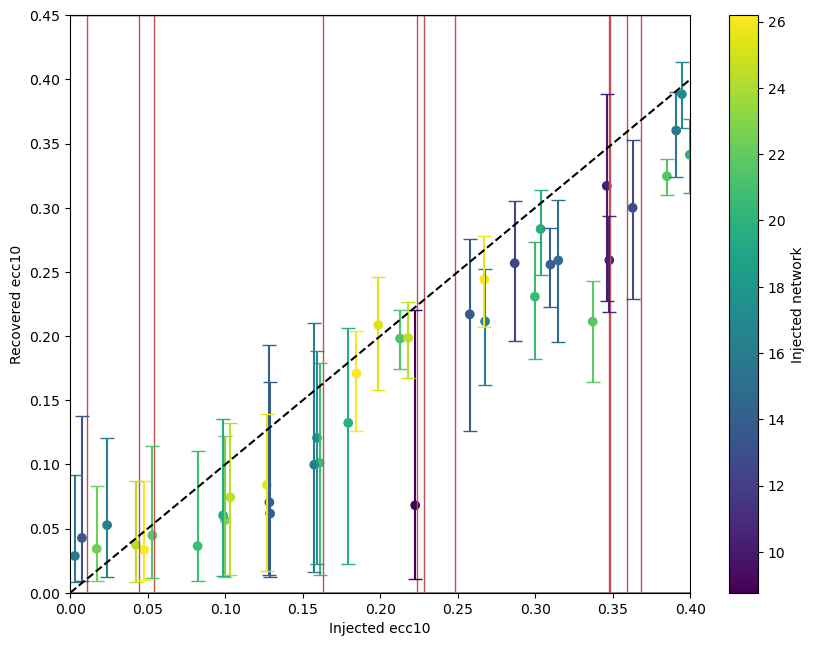

In [194]:
err_lbl = 'ecc10'
inj_lbl = 'ecc10'
colour_lbl = 'network'
err_type = 'base'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50/injections'
xlims = [0, 0.4]
ylims = [0, 0.45]
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)

50it [00:05,  9.66it/s]


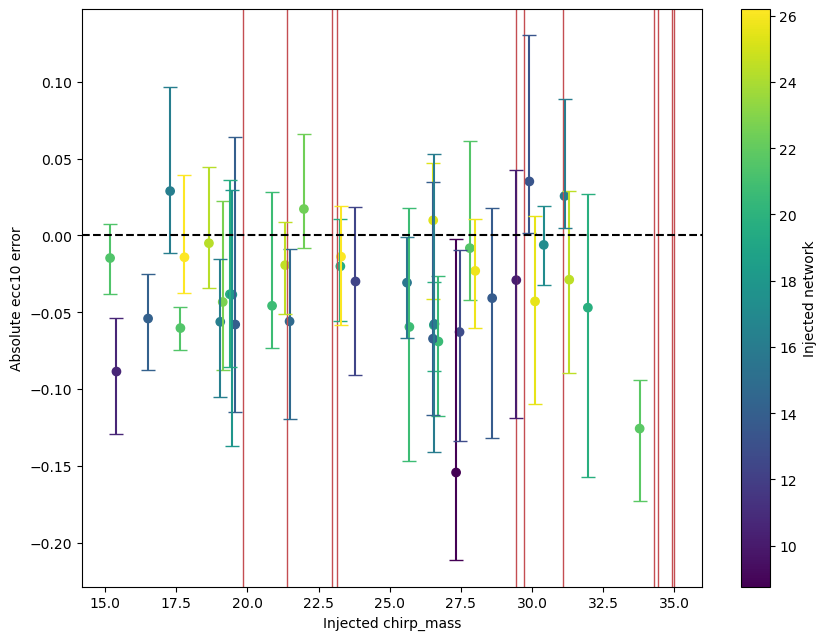

In [188]:
err_lbl = 'ecc10'
inj_lbl = 'chirp_mass'
colour_lbl = 'network'
err_type = 'abs'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50/injections'
xlims = None
ylims = None
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)

50it [00:05,  9.52it/s]


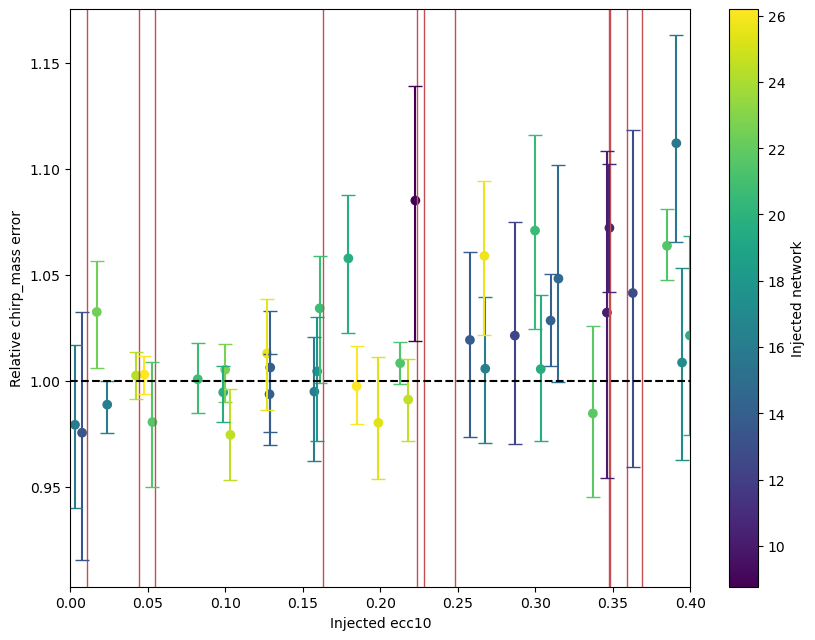

In [189]:
err_lbl = 'chirp_mass'
inj_lbl = 'ecc10'
colour_lbl = 'network'
err_type = 'rel'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50/injections'
xlims = [0, 0.4]
ylims = None
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)

50it [00:04, 11.33it/s]


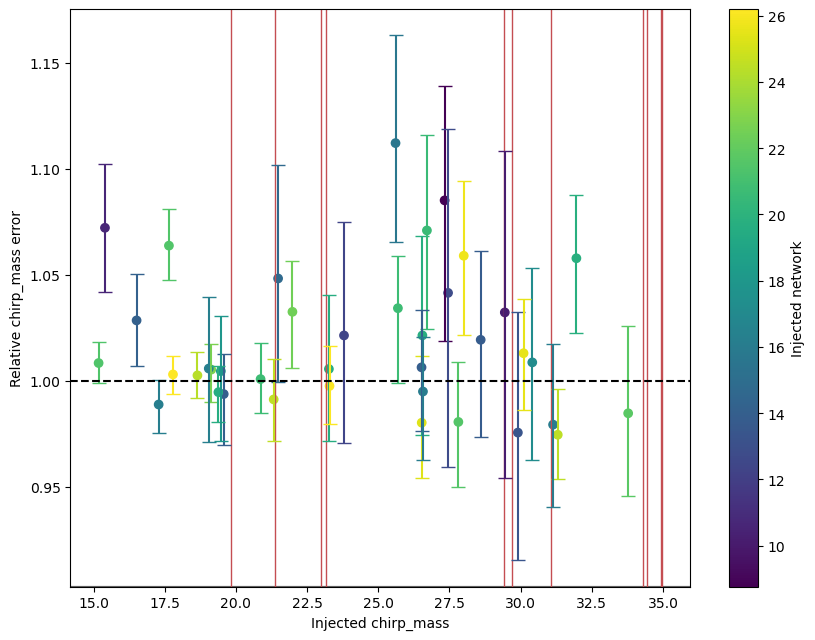

In [192]:
err_lbl = 'chirp_mass'
inj_lbl = 'chirp_mass'
colour_lbl = 'network'
err_type = 'rel'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50/injections'
xlims = None
ylims = None
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)